# FMRG Final Submission: Hierarchical Local Geometry Prediction

This executed notebook is the compact submission record for predicting spatially
varying DED track width, center, and left/right boundaries from causal thermal history.

**Evaluation protocol:** each of Tracks 8, 10, 14, and 21 is held out once. Feature
family, estimator, preprocessing, and calibration are selected by leave-one-track-out
validation using only the other three tracks. Headline metrics are unweighted means
across the four untouched outer tracks.

## Reproducibility

Recreate the tracked outputs from the official Zenodo release with:

```bash
PYTHONPATH=src LOKY_MAX_CPU_COUNT=1 MPLBACKEND=Agg               .venv/bin/python scripts/run_improvement_experiments.py               --raw-dir /path/to/extracted/zenodo/data               --cache-dir /path/to/cache               --output-dir results/improved_submission
```

The notebook reads the tracked outer-fold predictions and locked metrics so it can
execute without redistributing the large raw archives.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
if not (ROOT / "results/improved_submission/metrics.json").exists():
    ROOT = ROOT.parent

RESULTS = ROOT / "results/improved_submission"
metrics = json.loads((RESULTS / "metrics.json").read_text())
predictions = pd.read_csv(RESULTS / "outer_fold_predictions.csv")
metrics["protocol"]

{'name': 'nested leave-one-track-out',
 'outer_tracks': [8, 10, 14, 21],
 'selection': 'inner leave-one-track-out on the other three tracks',
 'primary_metric': 'unweighted mean of per-track width MAE',
 'coverage_target': 0.9,
 'accuracy_tolerance_mm': 0.02,
 'steady_state_x_mm': [24.0, 96.0],
 'random_seed': 42}

## Model: condition baseline plus local residual

A single regressor tends to blur two effects: the mean width shift between laser
conditions and the smaller spatial fluctuations within a track. The promoted model
separates them:

1. track-level thermal summaries predict baseline center and baseline log-width;
2. frame-level thermal history predicts local center and log-width residuals;
3. width is reconstructed with an exponential transform, so it is positive; and
4. left/right boundaries are reconstructed from shared center and width, so they
   cannot cross.

The candidate ladder includes Ridge, elastic net, partial least squares,
spline-Ridge, and a low-capacity Gaussian process. Thermal descriptors include melt
pool shape, temperature distribution, gradients, asymmetry, cooling tail, motion,
persistence, and causal 5-, 10-, and 20-frame history.

In [2]:
incumbent = metrics["incumbent"]["metrics"]
promoted = metrics["candidates"]["nested_metrics"]

rows = []
for name, values in [
    ("Direct Ridge incumbent", incumbent),
    ("Nested hierarchical selector", promoted),
]:
    rows.append(
        {
            "model": name,
            "track_balanced_width_MAE_mm": values["track_balanced_width_mae_mm"],
            "worst_track_MAE_mm": values["worst_track_width_mae_mm"],
            "mean_boundary_MAE_mm": values["mean_boundary_mae_mm"],
            "residual_correlation": values["residual_correlation"],
            "variation_std_ratio": values["variation_std_ratio"],
        }
    )
comparison = pd.DataFrame(rows).set_index("model")
comparison.round(4)

,track_balanced_width_MAE_mm,worst_track_MAE_mm,mean_boundary_MAE_mm,residual_correlation,variation_std_ratio
model,,,,,
Direct Ridge incumbent,0.1871,0.3080,0.1800,0.0547,0.2141
Nested hierarchical selector,0.1627,0.2191,0.1483,0.1235,0.3564


In [3]:
improvement = 100 * (
    incumbent["track_balanced_width_mae_mm"]
    - promoted["track_balanced_width_mae_mm"]
) / incumbent["track_balanced_width_mae_mm"]
worst_improvement = 100 * (
    incumbent["worst_track_width_mae_mm"]
    - promoted["worst_track_width_mae_mm"]
) / incumbent["worst_track_width_mae_mm"]
boundary_improvement = 100 * (
    incumbent["mean_boundary_mae_mm"]
    - promoted["mean_boundary_mae_mm"]
) / incumbent["mean_boundary_mae_mm"]
print(f"Track-balanced width MAE improvement: {improvement:.1f}%")
print(f"Worst-track MAE improvement: {worst_improvement:.1f}%")
print(f"Mean boundary MAE improvement: {boundary_improvement:.1f}%")

Track-balanced width MAE improvement: 13.1%
Worst-track MAE improvement: 28.9%
Mean boundary MAE improvement: 17.6%


## Four untouched outer tests

The promoted selector uses normalized compact thermal features with spline-Ridge in
three of four outer folds. Track 14 independently selects normalized multiscale
features with Ridge. This is the honest output of nested selection, not a single
configuration tuned against all four labels.

In [4]:
per_track = promoted["per_track"]
pd.DataFrame(
    [
        {
            "track": int(track),
            "width_MAE_mm": values["width_mae_mm"],
            "boundary_MAE_mm": values["mean_boundary_mae_mm"],
            "residual_correlation": values["residual_correlation"],
            "variation_std_ratio": values["variation_std_ratio"],
        }
        for track, values in per_track.items()
    ]
).sort_values("track").round(4)

,track,width_MAE_mm,boundary_MAE_mm,residual_correlation,variation_std_ratio
0,8,0.1548,0.1035,0.1725,0.5989
1,10,0.1117,0.1120,0.1898,0.3916
2,14,0.1651,0.1274,0.0299,0.2849
3,21,0.2191,0.2505,0.1018,0.1502


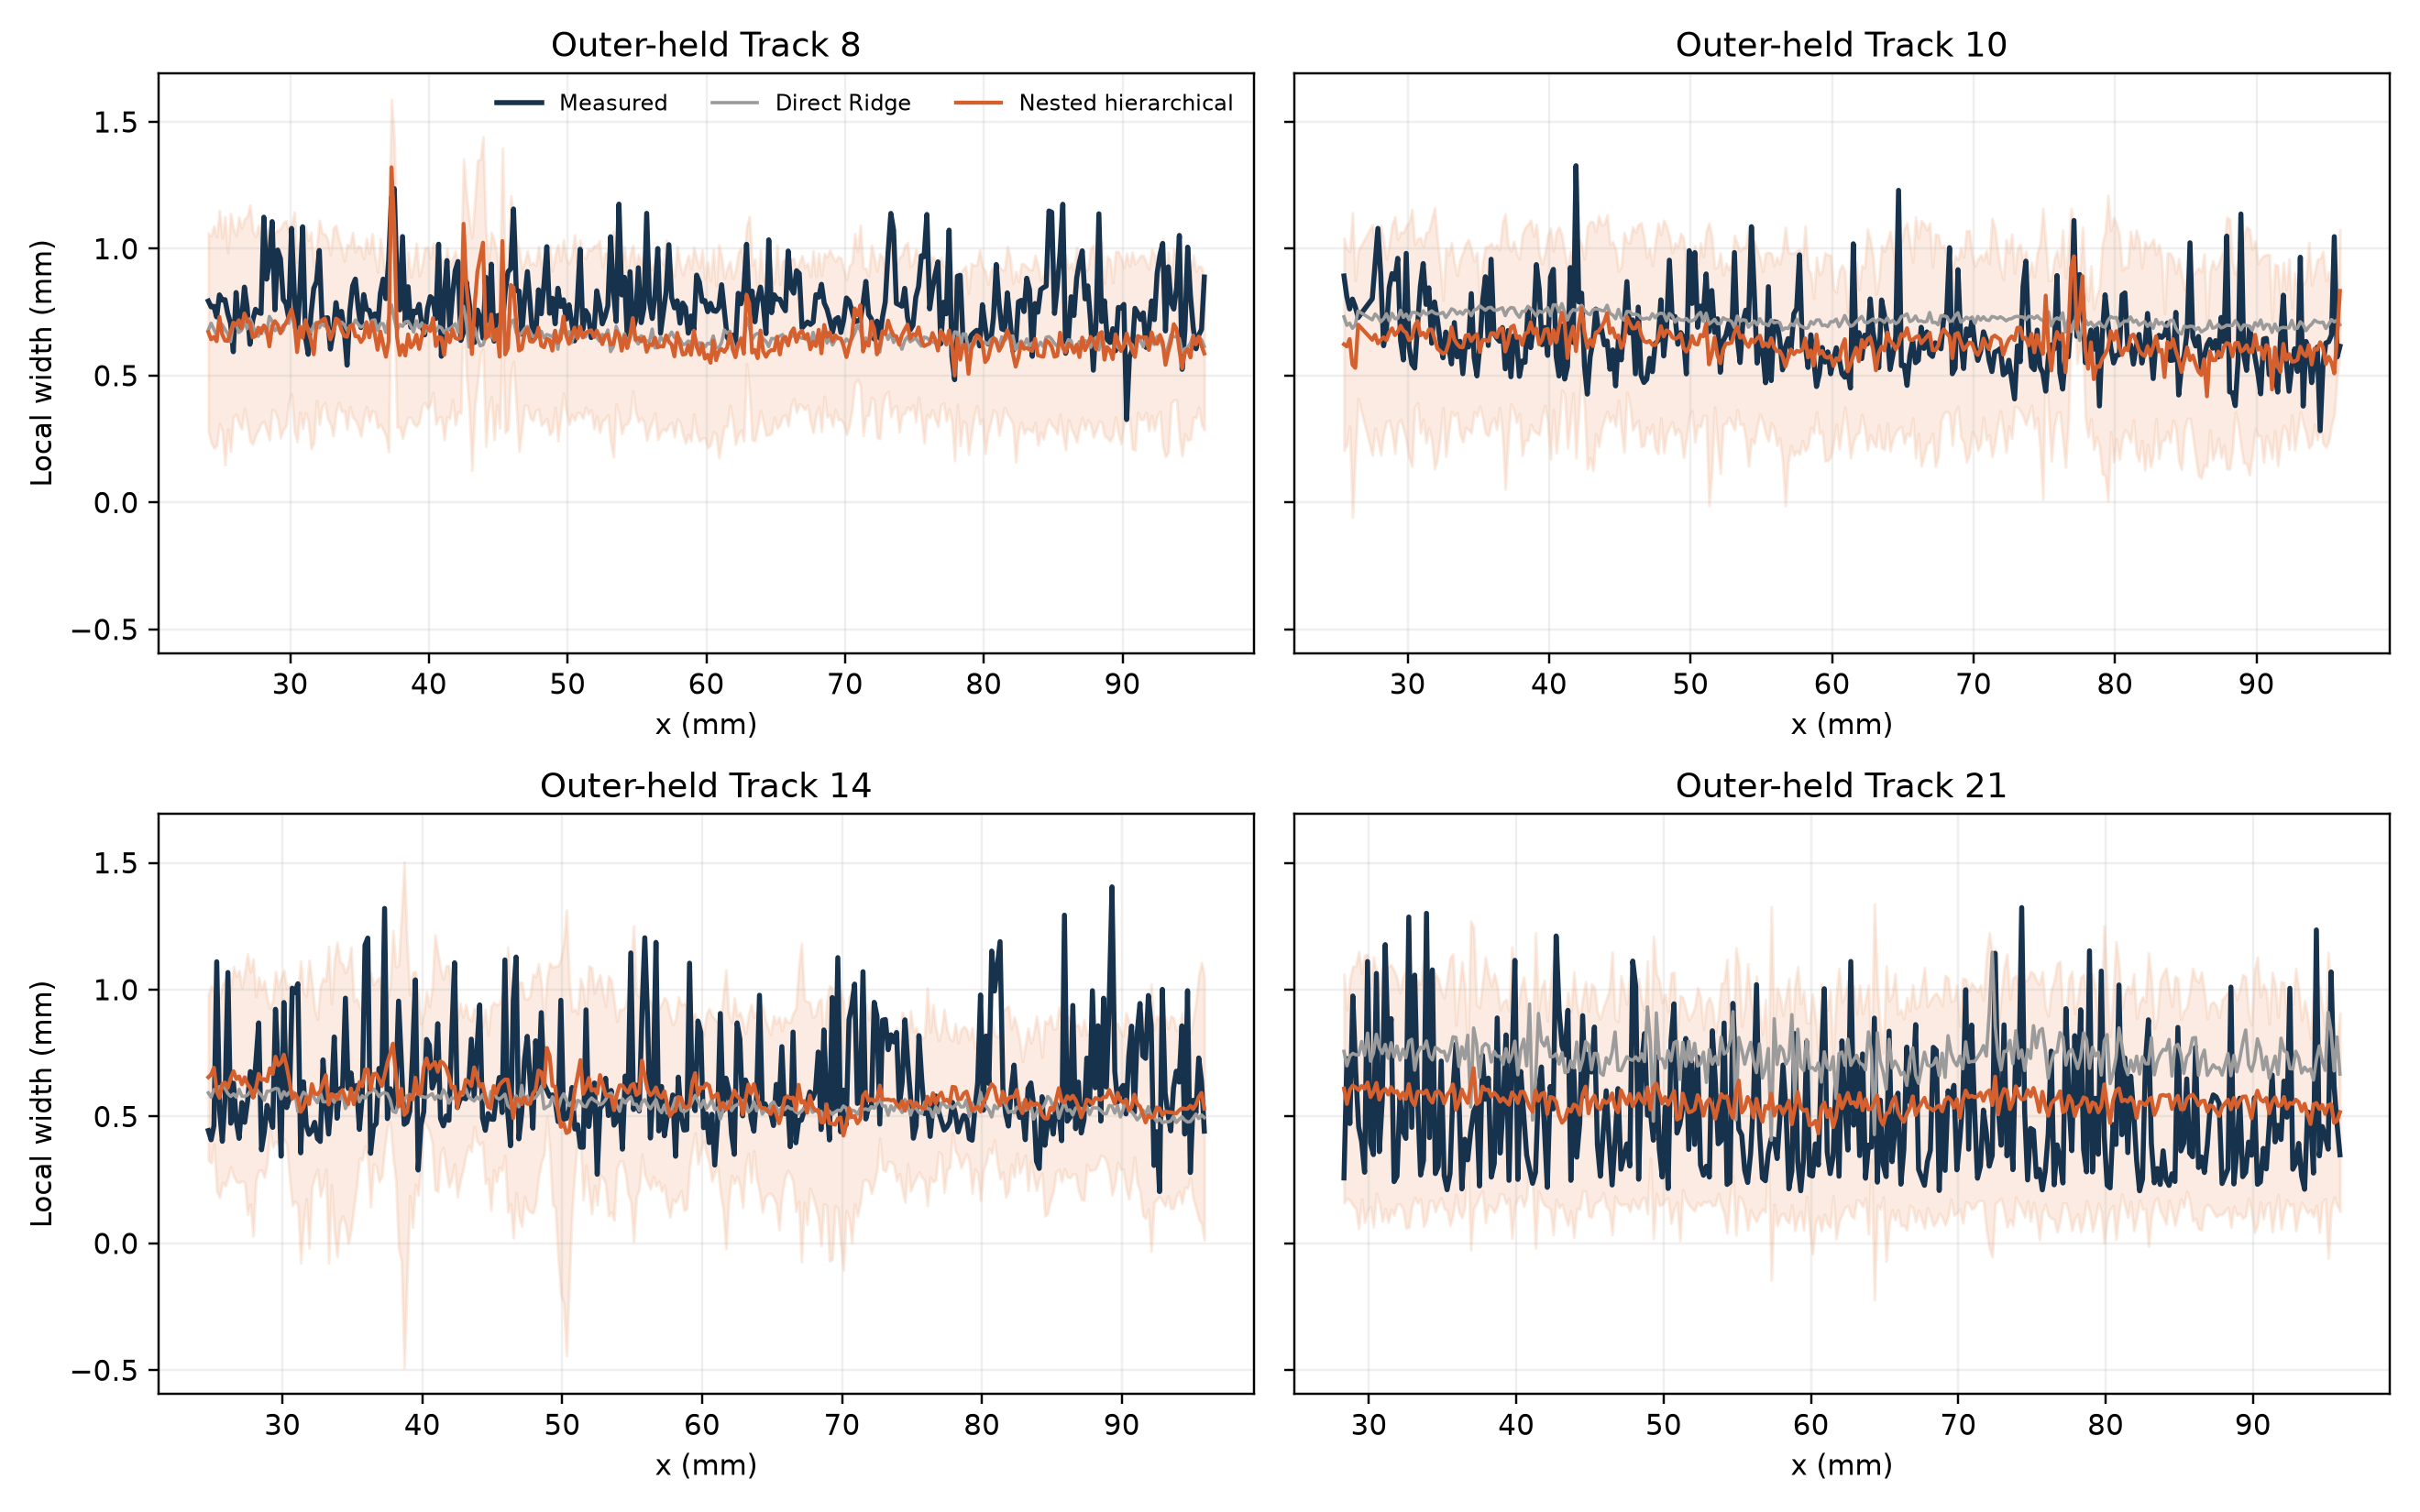

In [5]:
display(
    Image(
        filename=str(RESULTS / "figures/nested_outer_predictions.png"),
        width=1100,
    )
)

## Conditional uncertainty

Normalized conformal calibration scales intervals by predicted local difficulty.
The selected conditional method is closer to the 90% target and narrower on average
than a single global interval. Interval width grows from easy to difficult regions,
which is the intended behavior.

In [6]:
uncertainty = metrics["uncertainty"]
summary = pd.DataFrame(
    [
        {"method": "conditional", **uncertainty["conditional"]},
        {"method": "global", **uncertainty["global"]},
    ]
).set_index("method")
display(summary.round(4))
display(
    pd.DataFrame(uncertainty["conditional_by_difficulty"])
    .T.rename_axis("difficulty")
    .round(4)
)

,coverage,mean_width_mm
method,,
conditional,0.9144,0.7377
global,0.9422,0.8239


,coverage,mean_width_mm
difficulty,,
low,0.8868,0.6100
medium,0.9058,0.6916
high,0.9507,0.9118


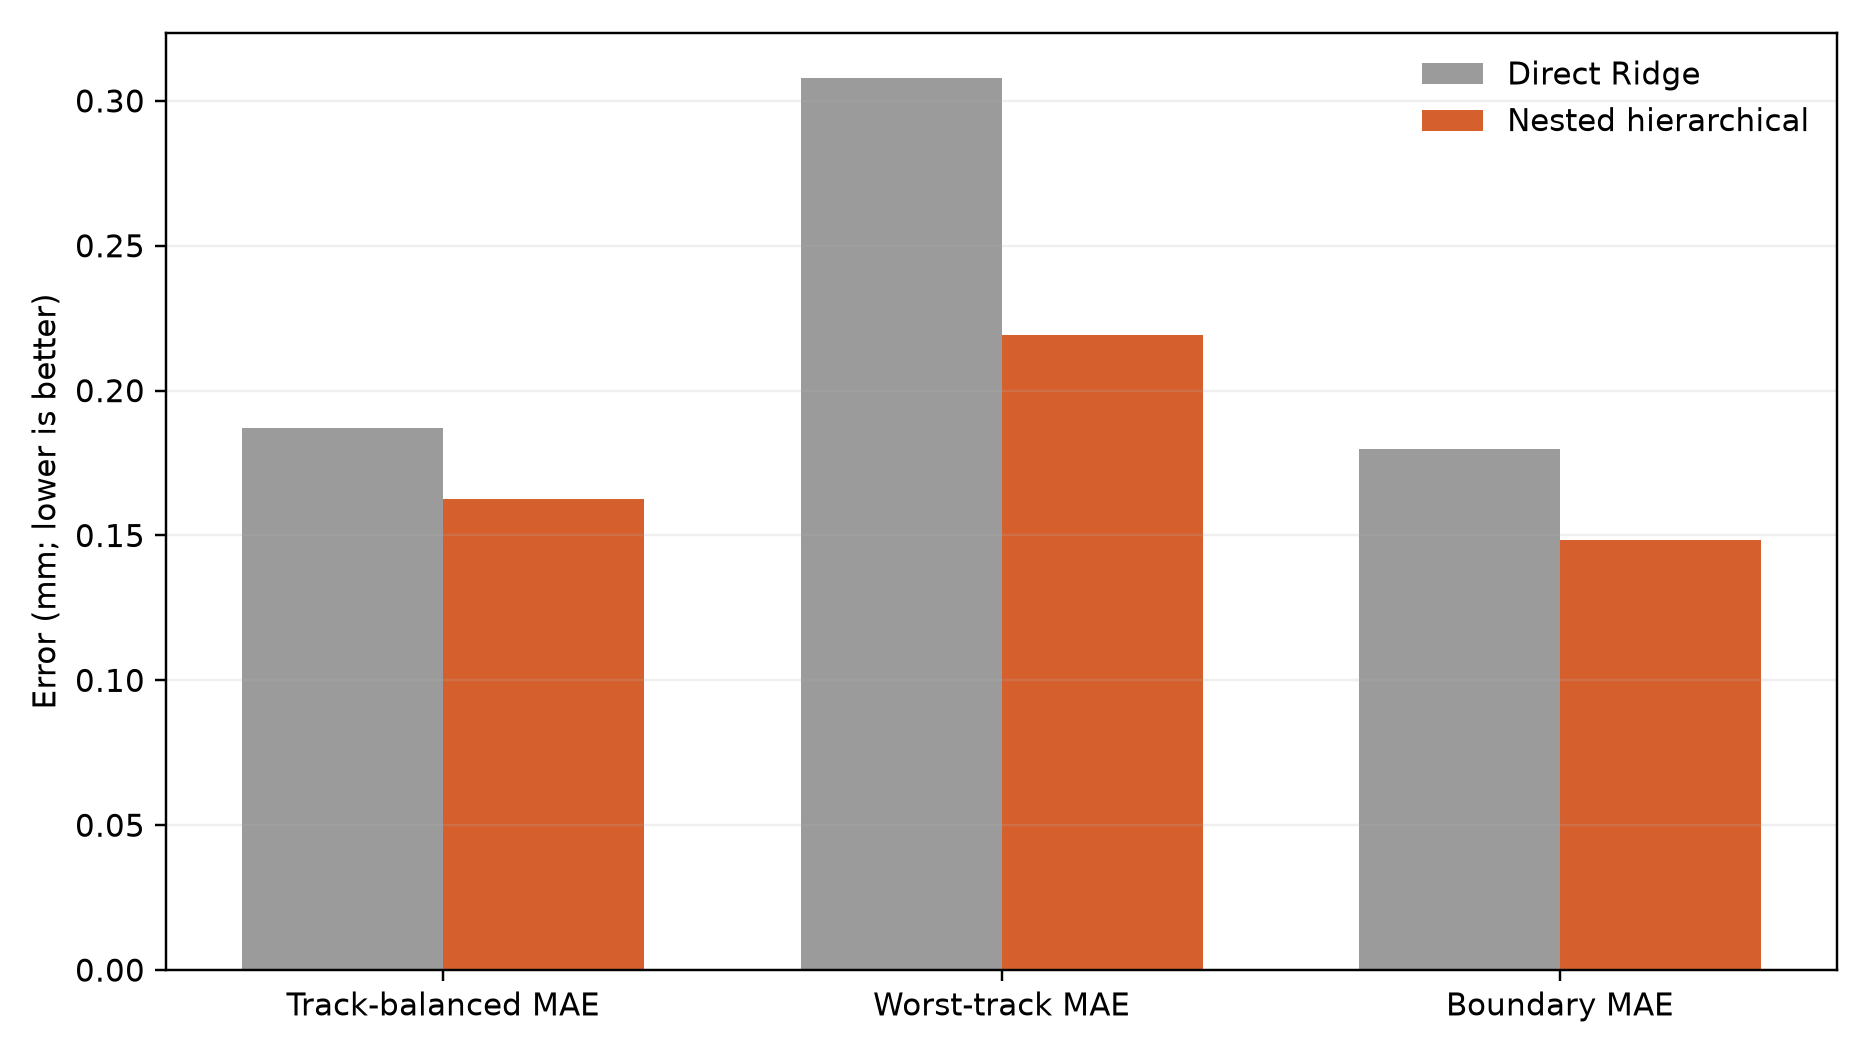

In [7]:
display(
    Image(
        filename=str(RESULTS / "figures/before_after_scorecard.png"),
        width=1000,
    )
)

## SEM ablation and interpretation

The available SEM is post-process. The processed center band is masked and the
remaining flank texture is evaluated only as an ablation. It is selected in zero
outer folds. Therefore this submission makes no causal claim that pre-existing
substrate texture drives geometry.

Interpretable thermal links come from the selected descriptor families: track-level
hot area, maximum temperature, thermal mass, and cooling-tail summaries explain the
condition baseline; normalized local shape, temperature, asymmetry, and history
explain residual variation. These are predictive associations, not causal effects.

In [8]:
metrics["sem_ablation"]

{'source': 'post-process SEM with the processed center masked',
 'preprocess_sem_available': False,
 'outer_folds_selecting_sem': 0,
 'selected_by_any_outer_fold': False,
 'causal_substrate_claim': False}

## Historical Track 21 benchmark

The earlier audited split achieved 0.139 mm Track 21 MAE versus 0.159 mm for the
original notebook. That number is retained only as a historical benchmark. Under the
stronger four-track nested protocol, Track 21 receives no special tuning and scores
0.219 mm. The two numbers answer different questions and must not be combined.

In [9]:
metrics["historical_benchmark"]

{'original_notebook_mae_mm': 0.1589159,
 'audited_ridge_mae_mm': 0.1393538,
 'mae_improvement_percent': 12.3097,
 'role': 'historical benchmark only; not used for model selection'}

## Honest conclusion

- Four-track width MAE improves from **0.187 mm to 0.163 mm** (**13.1%**).
- Worst-track MAE improves from **0.308 mm to 0.219 mm** (**28.9%**).
- Mean boundary MAE improves from **0.180 mm to 0.148 mm** (**17.6%**).
- Residual correlation improves from **0.055 to 0.124**, and predicted variation
  amplitude rises from **21% to 36%** of measured variation.
- Conditional intervals achieve **91.4%** coverage with **0.738 mm** mean width,
  versus **94.2%** and **0.824 mm** for the global interval.
- Track-balanced R-squared remains **-0.34**; this is a stronger benchmark, not a
  closed-loop-ready controller.

The next decisive experiment is registered pre-process surface measurement across
more plates, powers, and repeats.

## Generative AI disclosure

OpenAI Codex assisted with code review, test generation, debugging, and artifact
layout. Reported metrics were produced by tracked analysis code and saved outer-fold
predictions; AI did not supply or alter experimental measurements.

## Sources

- Official dataset: https://doi.org/10.5281/zenodo.21285367
- Dataset paper: https://arxiv.org/abs/2607.07965
- Locked metrics: `results/improved_submission/metrics.json`
- Outer predictions: `results/improved_submission/outer_fold_predictions.csv`